# W1D1 — Setup & Your First Model — Lab

**Week 1 · Day 1 · ML Foundations & the Data Toolkit** · Lab

Today you build a complete machine learning model end to end: load real data, split it honestly,
train a model, and measure whether it is any good. Every remaining lab in this bootcamp is a
variation on these five steps, so the point today is the *shape* of the work, not the sophistication
of the model.

You will also do the thing most beginners skip: build a **deliberately stupid baseline first**, so
that when your real model scores something, you know whether that number is impressive or embarrassing.

You'll leave with `baseline.json` — the score your later models have to beat.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ١ — الإعداد وأول نموذج لك

**الأسبوع ١ · اليوم ١ · أساسيات تعلّم الآلة وأدوات البيانات** · معمل عملي

اليوم تبني نموذج تعلّم آلة كاملًا من البداية إلى النهاية: تحميل بيانات حقيقية، ثم تقسيمها بنزاهة، ثم
تدريب نموذج، ثم قياس ما إذا كان جيدًا فعلًا. كل معمل لاحق في هذا المعسكر هو تنويعة على هذه الخطوات
الخمس، لذا فالمهم اليوم هو **شكل العمل** لا تعقيد النموذج.

وستفعل أيضًا ما يتخطّاه معظم المبتدئين: بناء **خط أساس غبي عمدًا أولًا**، حتى إذا حقّق نموذجك الحقيقي
رقمًا ما عرفت هل هذا الرقم مُبهر أم محرج.

ستخرج بملف `baseline.json` — وهي النتيجة التي على نماذجك القادمة أن تتفوّق عليها.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Load a dataset and describe what one row represents before modelling it.
- Split data into training and test sets, and explain why evaluating on training data is meaningless.
- Train a `LinearRegression` model with scikit-learn and predict on unseen rows.
- Compare a model against a dumb baseline using MAE, RMSE, and R², and say what each one means in
  the units of the problem.
- Spot a data problem that silently limits how good any model can be.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- تحميل مجموعة بيانات ووصف ما يمثّله الصف الواحد قبل النمذجة.
- تقسيم البيانات إلى تدريب واختبار، وشرح لماذا لا معنى للتقييم على بيانات التدريب.
- تدريب نموذج `LinearRegression` باستخدام scikit-learn والتنبّؤ على صفوف لم يرها النموذج.
- مقارنة النموذج بخط أساس غبي باستخدام MAE وRMSE وR²، وبيان معنى كل مقياس بوحدات المسألة نفسها.
- اكتشاف مشكلة في البيانات تحدّ بصمت من أقصى جودة يمكن لأي نموذج بلوغها.

</div>

## About the data

**Dataset:** `housing_prices` — California Housing (StatLib, derived from the 1990 US Census) ·
public domain · 20,640 rows

Each row is a **census block group** — roughly 600 to 3,000 people living close together — not a
single house. The columns describe that block: median income of its households, median house age,
average rooms per household, population, and its latitude and longitude. The target,
`median_house_value`, is the median price of a home in that block, in US dollars.

Predicting it matters because it is the shape of an enormous class of real problems: *given some
measurable properties of a thing, estimate a number about it.* Property valuation, demand forecasting,
credit limits, and delivery-time estimates are all this same shape.

**Watch out:** the target is **capped at $500,001**. Every block worth more than that was recorded as
exactly that value. Nearly a thousand rows sit on that wall. No model can predict past a ceiling that
does not exist in the data — you will see the damage in Section 1 and measure it in Section 3.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `housing_prices` — مساكن كاليفورنيا (من تعداد ١٩٩٠) · ملكية عامة · ٢٠٬٦٤٠ صفًا

كل صف يمثّل **مجموعة مربّعات سكنية في التعداد** — أي ما بين ٦٠٠ و٣٠٠٠ شخص يسكنون متجاورين — وليس منزلًا
واحدًا. وتصف الأعمدة تلك المجموعة: متوسط دخل أسرها، ومتوسط عمر المساكن، ومتوسط عدد الغرف لكل أسرة،
وعدد السكان، وخط العرض وخط الطول. أما الهدف `median_house_value` فهو متوسط سعر المسكن في تلك المجموعة
بالدولار.

يهمّ التنبّؤ به لأنه يمثّل شكلًا لصنف ضخم من المسائل الواقعية: *بمعلومية خصائص قابلة للقياس لشيء ما،
قدّر رقمًا يخصّه.* فتقييم العقارات والتنبّؤ بالطلب وحدود الائتمان وتقدير أزمنة التوصيل كلها بهذا الشكل نفسه.

**انتبه:** الهدف **مقصوص عند ٥٠٠٬٠٠١ دولار**. فكل مجموعة قيمتها أعلى من ذلك سُجّلت بهذه القيمة بالضبط،
ويقف نحو ألف صف على هذا الجدار. ولا يستطيع أي نموذج التنبّؤ بما بعد سقف غير موجود أصلًا في البيانات —
وسترى الضرر في القسم الأول وتقيسه في القسم الثالث.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and finds the dataset —
whether you are on your own machine or on Google Colab.

If it fails with `ModuleNotFoundError: aiep`, check that your kernel is **Python (aiep)**
(*Kernel → Change kernel*), or re-run `uv pip install -e shared/`.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتجد ملف البيانات — سواء كنت على
جهازك أو على Google Colab.

إذا ظهر الخطأ `ModuleNotFoundError: aiep` فتحقّق أن النواة المختارة هي **Python (aiep)**
(من قائمة *Kernel ← Change kernel*)، أو أعد تنفيذ الأمر `uv pip install -e shared/`.

</div>

In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, check_shape, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("housing_prices")
print(describe_dataset("housing_prices"))
print("\n", versions())

⬇️  Downloading housing_prices.parquet (0.81 MB) …
✅ housing_prices: downloaded to /content/aiep_data/housing_prices.parquet
housing_prices  (20640 rows, 0.81 MB)
  Source:  California Housing via sklearn.datasets.fetch_california_housing
  Licence: Public domain (StatLib, 1990 US Census derived)
  Target:  median_house_value

  EN: Housing blocks with median price as the target. The regression counterpart to telco_churn: used for the first end-to-end model (W1D1) and for gradient descent from scratch (W1D2), where a single feature keeps the arithmetic visible.
  AR: بيانات أحياء سكنية مع متوسط السعر كهدف. النظير الانحداري لمجموعة telco_churn، وتُستخدم في أول نموذج متكامل (الأسبوع ١ اليوم ١) وفي طريقة النزول التدريجي من الصفر (الأسبوع ١ اليوم ٢) حيث تُبقي خاصية واحدة الحساب مرئيًا.

  ⚠️  Watch out: The target is capped at 500001 — a wall of points at the maximum that quietly breaks the fit.
  ⚠️  انتبه: الهدف مقصوص عند القيمة ٥٠٠٠٠١، فتتكدّس نقاط كثيرة عند الحد الأقصى وتُفسد المطابقة 

## Section 1 — Warm-up: look before you model  (≈25 min)

Everything in this section already works. Run it, read it, and answer the question at the end of each
cell in your head before you scroll on.

The habit being built here is simple and almost universally skipped: **never fit a model to data you
have not looked at.**

<div dir="rtl" align="right">

## القسم الأول — التهيئة: انظر قبل أن تُنمذج (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا. شغّله واقرأه، وأجب في ذهنك عن السؤال في نهاية كل خلية قبل أن تتابع.

والعادة التي نبنيها هنا بسيطة ويتخطّاها الجميع تقريبًا: **لا تُدرّب نموذجًا على بيانات لم تنظر إليها.**

</div>

In [2]:
df = pd.read_parquet(DATA)

print(f"rows: {df.shape[0]:,}   columns: {df.shape[1]}")
print(f"missing values: {df.isna().sum().sum()}")
df.head()

rows: 20,640   columns: 9
missing values: 0


,median_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


`describe()` gives you the shape of every column at a glance. Read the `min` and `max` rows
carefully — that is where broken data usually announces itself.

<div dir="rtl" align="right">

تعطيك `describe()` صورة سريعة عن كل عمود. اقرأ صفّي `min` و`max` بتمعّن — فهناك عادةً تُعلن البيانات
المعطوبة عن نفسها.

</div>

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
avg_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
avg_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
avg_occupancy,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
median_house_value,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000


### Task 1.1 — find the ceiling

The scatter plot below puts median income against house value. Somewhere in it is the problem the
"About the data" section warned you about.

Look at the top of the plot before you read on.

<div dir="rtl" align="right">

### المهمة ١٫١ — اعثر على السقف

يضع الرسم أدناه متوسط الدخل مقابل قيمة المسكن. وفيه تظهر المشكلة التي حذّرك منها قسم «عن البيانات».

انظر إلى أعلى الرسم قبل أن تتابع القراءة.

</div>

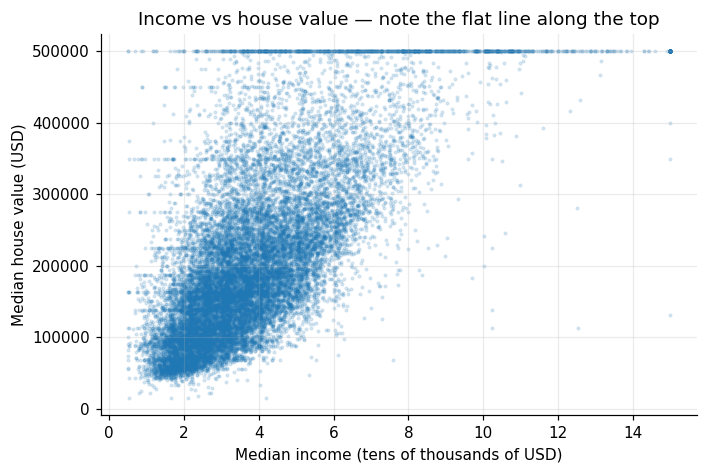

992 rows sit exactly on the cap (4.8% of the data)


In [4]:
fig, ax = plt.subplots()
ax.scatter(df["median_income"], df["median_house_value"], s=3, alpha=0.15)
ax.set_xlabel("Median income (tens of thousands of USD)")
ax.set_ylabel("Median house value (USD)")
ax.set_title("Income vs house value — note the flat line along the top")
plt.show()

capped = (df["median_house_value"] >= 500_000).sum()
print(f"{capped:,} rows sit exactly on the cap ({capped / len(df):.1%} of the data)")

That solid horizontal line along the top is not a pattern in the housing market. It is a
**recording limit**: any block worth more than \$500,001 was written down as \$500,001.

This matters more than it looks. Roughly 5% of your rows have a target that is *wrong in a known
direction* — too low. A model trained on them learns to under-predict expensive areas, and no amount
of tuning fixes it, because the information was destroyed before you got the file.

You will measure exactly how much this costs you in Section 3.

<div dir="rtl" align="right">

هذا الخط الأفقي الصلب في الأعلى ليس نمطًا في سوق الإسكان، بل هو **حدّ تسجيل**: فكل مجموعة قيمتها أعلى
من ٥٠٠٬٠٠١ دولار كُتبت بالقيمة ٥٠٠٬٠٠١.

وهذا أخطر مما يبدو. فنحو ٥٪ من صفوفك لها هدف **خاطئ باتجاه معلوم** — أقل من الحقيقة. والنموذج المُدرَّب
عليها يتعلّم أن يقلّل من تقدير المناطق الغالية، ولا يُصلح ذلك أي قدر من الضبط، لأن المعلومة أُتلفت قبل
أن يصلك الملف أصلًا.

وستقيس تكلفة ذلك بالضبط في القسم الثالث.

</div>

## Section 2 — Core: the five steps  (≈60 min)

Every supervised machine learning project is these five steps. Today you do all of them once, on the
simplest possible model, so that the shape is familiar before the models get interesting.

1. Separate the features from the target.
2. Split into training and test sets.
3. Build a **dumb baseline** to beat.
4. Train the real model.
5. Measure both on the test set and compare.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: الخطوات الخمس (نحو ٦٠ دقيقة)

كل مشروع تعلّم آلة موجَّه هو هذه الخطوات الخمس. اليوم تنفّذها كلها مرة واحدة على أبسط نموذج ممكن، حتى
يصبح الشكل مألوفًا قبل أن تصبح النماذج مثيرة.

١. افصل الخصائص عن الهدف.
٢. قسّم البيانات إلى تدريب واختبار.
٣. ابنِ **خط أساس غبيًا** لتتفوّق عليه.
٤. درّب النموذج الحقيقي.
٥. قِس الاثنين على مجموعة الاختبار وقارن.

</div>

### Task 2.1 — separate features from the target

`X` holds everything the model is allowed to see. `y` holds the thing it must predict. Getting this
wrong — leaving the answer inside `X` — is the single most common way a beginner gets a suspiciously
perfect score.

<div dir="rtl" align="right">

### المهمة ٢٫١ — افصل الخصائص عن الهدف

يحتوي `X` على كل ما يُسمح للنموذج برؤيته، ويحتوي `y` على ما عليه التنبّؤ به. والخطأ هنا — بترك الإجابة
داخل `X` — هو أشيع سبب لحصول المبتدئ على نتيجة مثالية بشكل مريب.

</div>

In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) `y` is the single column you are predicting: median_house_value.
# 2) `X` is every other column. Think about what a DataFrame method called "drop" does.
# 3) Check the shapes afterwards — X must have one column fewer than df.
# Search: "pandas drop column"
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html
#
# ١) `y` هو العمود الوحيد الذي تتنبّأ به: median_house_value.
# ٢) `X` هو بقية الأعمدة. فكّر فيما تفعله دالة اسمها "drop" في DataFrame.
# ٣) تحقّق من الأبعاد بعدها — يجب أن يقلّ عدد أعمدة X عن df بعمود واحد.
# ابحث عن: "pandas drop column"
# ────────────────────────────────────────────────────────────────────

TARGET = "median_house_value"
y = df[TARGET]
X = df.drop(columns=TARGET)
print("X:", X.shape, "| y:", y.shape)
print("features:", list(X.columns))

X: (20640, 8) | y: (20640,)
features: ['median_income', 'house_age', 'avg_rooms', 'avg_bedrooms', 'population', 'avg_occupancy', 'latitude', 'longitude']


### Task 2.2 — split into training and test sets

The model learns from the training set. The test set is locked away and used exactly once, at the
end, to answer one question: *how well does this do on rows it has never seen?*

If you evaluate on the training data you are asking the model to recite what it memorised. That number
is always good and always meaningless.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — قسّم البيانات إلى تدريب واختبار

يتعلّم النموذج من مجموعة التدريب، أما مجموعة الاختبار فتُحفظ جانبًا وتُستخدم مرة واحدة فقط في النهاية
للإجابة عن سؤال واحد: *ما مدى جودة أدائه على صفوف لم يرها قط؟*

فإذا قيّمت على بيانات التدريب فأنت تطلب من النموذج أن يسمّع ما حفظه، وهذا الرقم جيّد دائمًا وبلا معنى دائمًا.

</div>

In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) Keep 20% of the rows for testing and train on the other 80%.
# 2) Pass a fixed random_state so you get the same split every time you re-run —
#    otherwise your score changes on every run and you cannot tell if a change helped.
# 3) The function returns four things, in the order train-X, test-X, train-y, test-y.
# Search: "scikit-learn train test split"
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
#
# ١) احتفظ بـ ٢٠٪ من الصفوف للاختبار ودرّب على الـ ٨٠٪ الباقية.
# ٢) مرّر قيمة ثابتة لـ random_state لتحصل على التقسيم نفسه في كل تشغيل —
#    وإلا تغيّرت نتيجتك في كل مرة ولن تعرف هل ساعد تعديلك أم لا.
# ٣) تُعيد الدالة أربعة أشياء بالترتيب: X التدريب، X الاختبار، y التدريب، y الاختبار.
# ابحث عن: "scikit-learn train test split"
# ────────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
# TODO: Split X and y into an 80% training set and a 20% test set, with random_state=42.
# مهمة: قسّم X وy إلى ٨٠٪ تدريب و٢٠٪ اختبار، مع random_state=42.
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(f"train: {X_train.shape[0]:,} rows")
print(f"test:  {X_test.shape[0]:,} rows")

train: 16,512 rows
test:  4,128 rows


### Task 2.3 — the dumb baseline

Before training anything clever, answer this: **what score do you get by not trying at all?**

The laziest possible predictor ignores every feature and guesses the average training price for every
single block. It is useless as a product and essential as a yardstick — it is the number your real
model has to beat before anyone should be impressed.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — خط الأساس الغبي

قبل تدريب أي شيء ذكي، أجب عن هذا: **ما النتيجة التي تحصل عليها إن لم تحاول أصلًا؟**

أكسل مُتنبّئ ممكن يتجاهل كل الخصائص ويخمّن متوسط سعر التدريب لكل مجموعة سكنية. وهو عديم الفائدة كمنتج،
لكنه ضروري كمسطرة قياس — فهو الرقم الذي يجب أن يتفوّق عليه نموذجك الحقيقي قبل أن يُعجب به أحد.

</div>

In [10]:
# ────────────────────────────────────────────────────────────────────
# 1) The baseline prediction for EVERY test row is the same single number:
#    the mean of the TRAINING target. Never the test target — that would be cheating.
# 2) You need an array of that number, one per test row. np.full_like or np.full will do it.
# 3) MAE is the average size of the error, in dollars. Read it as "on average we are off by X".
# Search: "sklearn mean_absolute_error"
#
# ١) تنبّؤ خط الأساس لكل صف اختبار هو الرقم نفسه: متوسط هدف **التدريب**.
#    ولا تستخدم هدف الاختبار أبدًا — فذلك غش.
# ٢) تحتاج مصفوفة من هذا الرقم بطول صفوف الاختبار، وتفي np.full بالغرض.
# ٣) MAE هو متوسط حجم الخطأ بالدولار، ويُقرأ: «نخطئ في المتوسط بمقدار كذا».
# ابحث عن: "sklearn mean_absolute_error"
# ────────────────────────────────────────────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
baseline_value = y_train.mean()
baseline_pred = np.full(len(y_test), baseline_value)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline always guesses: ${baseline_value:,.0f}")
print(f"Baseline MAE:            ${baseline_mae:,.0f}")


Baseline always guesses: $207,195
Baseline MAE:            $90,607


### Task 2.4 — train the real model

`LinearRegression` fits a straight-line relationship: it finds one number (a *coefficient*) per
feature, multiplies each feature by its number, adds them up, and adds a constant. That is the whole
model.

Two method names carry almost all of scikit-learn: **`.fit(X, y)`** learns from data, and
**`.predict(X)`** applies what was learned. Every model in this bootcamp — trees, forests, neural
networks — uses the same two names.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — درّب النموذج الحقيقي

يُطابق `LinearRegression` علاقة خطية مستقيمة: يجد رقمًا واحدًا (*مُعاملًا*) لكل خاصية، ويضرب كل خاصية
في رقمها، ثم يجمع النواتج ويضيف ثابتًا. هذا هو النموذج كله.

واسمان لدالتين يحملان معظم مكتبة scikit-learn: **‏`.fit(X, y)`** تتعلّم من البيانات،
و**‏`.predict(X)`** تطبّق ما تعلّمته. وكل نموذج في هذا المعسكر — الأشجار والغابات والشبكات العصبية —
يستخدم الاسمين نفسيهما.

</div>

In [15]:
# ────────────────────────────────────────────────────────────────────
# 1) Create a LinearRegression object.
# 2) Fit it on the TRAINING data only. The test set must stay untouched.
# 3) Predict on the test features and store the result in `y_pred`.
# Search: "sklearn LinearRegression fit predict"
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
#
# ١) أنشئ كائن LinearRegression.
# ٢) درّبه على بيانات **التدريب** فقط، وابقِ مجموعة الاختبار دون مساس.
# ٣) تنبّأ على خصائص الاختبار واحفظ الناتج في `y_pred`.
# ابحث عن: "sklearn LinearRegression fit predict"
# ────────────────────────────────────────────────────────────────────

from sklearn.linear_model import LinearRegression
# TODO: Create the model and fit it on the training data.
# مهمة: أنشئ النموذج ودرّبه على بيانات التدريب.
model = LinearRegression()
model.fit(X_train, y_train)
print("first 5 predictions:", np.round(y_pred[:5]).astype(int))
print("first 5 actuals:    ", y_test.head().astype(int).values)

first 5 predictions: [ 71912 176402 270966 283893 260466]
first 5 actuals:     [ 47700  45800 500001 218600 278000]


### Task 2.5 — measure, and compare against the baseline

Three metrics, and each one answers a different question:

| Metric | Question it answers | Units |
|---|---|---|
| **MAE** | On average, how many dollars are we off by? | dollars |
| **RMSE** | Same, but large mistakes are punished much harder | dollars |
| **R²** | What fraction of the variation in price did we explain? | 0 to 1 |

RMSE is always ≥ MAE. When RMSE is *much* larger, a few big misses are dragging it up — which is
itself worth knowing.

A model is only interesting if it beats the baseline. Compute both and compare.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — قِس، وقارن بخط الأساس

ثلاثة مقاييس، ويجيب كل منها عن سؤال مختلف:

| المقياس | السؤال الذي يجيب عنه | الوحدة |
|---|---|---|
| **MAE** | بكم دولار نخطئ في المتوسط؟ | دولار |
| **RMSE** | السؤال نفسه، لكن مع معاقبة الأخطاء الكبيرة بقسوة أشدّ | دولار |
| **R²** | ما نسبة التباين في السعر التي فسّرناها؟ | من ٠ إلى ١ |

وقيمة RMSE دائمًا ≥ MAE. وحين تكون RMSE **أكبر بكثير** فذلك يعني أن أخطاءً كبيرة قليلة ترفعها — وهذه
معلومة تستحق المعرفة بحد ذاتها.

والنموذج لا يكون مثيرًا للاهتمام إلا إذا تفوّق على خط الأساس. احسب الاثنين وقارن.

</div>

In [16]:
# ────────────────────────────────────────────────────────────────────
# 1) Compute MAE, RMSE and R2 comparing y_test with y_pred.
# 2) RMSE is the square root of the mean squared error — sklearn gives you MSE, take np.sqrt.
# 3) Then compute MAE for the baseline predictions too, and print both side by side.
# Search: "sklearn regression metrics"
# https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
#
# ١) احسب MAE وRMSE وR² بمقارنة y_test بـ y_pred.
# ٢) قيمة RMSE هي الجذر التربيعي لمتوسط مربّع الخطأ — تعطيك sklearn قيمة MSE فخذ np.sqrt.
# ٣) ثم احسب MAE لتنبّؤات خط الأساس أيضًا واطبع النتيجتين جنبًا إلى جنب.
# ابحث عن: "sklearn regression metrics"
# ────────────────────────────────────────────────────────────────────

# TODO: Compute MAE, RMSE and R2 for the model's predictions.
# مهمة: احسب MAE وRMSE وR² لتنبّؤات النموذج.
model_mae = mean_absolute_error(y_test, y_pred)
model_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
model_r2 = r2_score(y_test, y_pred)
improvement = (baseline_mae - model_mae) / baseline_mae
print(f"Baseline MAE : ${baseline_mae:>10,.0f}")
print(f"Model MAE    : ${model_mae:>10,.0f}")
print(f"Model RMSE   : ${model_rmse:>10,.0f}")
print(f"Model R2     : {model_r2:>11.3f}")
print(f"\nThe model is {improvement:.1%} better than guessing the average.")

Baseline MAE : $    90,607
Model MAE    : $    53,320
Model RMSE   : $    74,558
Model R2     :       0.576

The model is 41.2% better than guessing the average.


### Task 2.6 — read what the model learned

A linear model is one of the few you can simply read. Each coefficient says: *if this feature goes up
by one unit and nothing else changes, the predicted price moves by this many dollars.*

Print them sorted by size and look at the top two or three. Do they match what you would expect about
housing?

**One warning that will matter all bootcamp:** these coefficients are on the features' original
scales, and the features are on wildly different scales — income is in tens of thousands, latitude is
in degrees. So a large coefficient does **not** by itself mean an important feature. And a
correlation in the data is not proof of a cause. You will do this properly in week 3.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — اقرأ ما تعلّمه النموذج

النموذج الخطي من النماذج القليلة التي يمكنك قراءتها مباشرة. فكل مُعامل يقول: *إذا زادت هذه الخاصية
بوحدة واحدة ولم يتغيّر شيء آخر، تحرّك السعر المتوقّع بهذا المقدار من الدولارات.*

اطبعها مرتّبة حسب الحجم وانظر إلى أكبر اثنين أو ثلاثة. هل تتّفق مع ما تتوقّعه عن سوق الإسكان؟

**تحذير سيهمّك طوال المعسكر:** هذه المُعاملات محسوبة على المقاييس الأصلية للخصائص، والخصائص على مقاييس
شديدة الاختلاف — فالدخل بعشرات الآلاف وخط العرض بالدرجات. لذا فالمُعامل الكبير **لا يعني** بذاته أن
الخاصية مهمة. كما أن الارتباط في البيانات ليس دليلًا على السببية. وستعالج هذا كما ينبغي في الأسبوع الثالث.

</div>

In [19]:
# ────────────────────────────────────────────────────────────────────
# 1) The fitted model exposes its coefficients as `model.coef_`, in the same order as X.columns.
# 2) Build a small DataFrame or Series pairing each column name with its coefficient.
# 3) Sort it so the largest magnitudes are easy to see.
# Search: "sklearn LinearRegression coef_"
#
# ١) يُتيح النموذج المُدرَّب مُعاملاته عبر `model.coef_` بالترتيب نفسه لـ X.columns.
# ٢) أنشئ جدولًا صغيرًا أو Series يربط كل اسم عمود بمُعامله.
# ٣) رتّبه حتى تظهر أكبر القيم المطلقة بوضوح.
# ابحث عن: "sklearn LinearRegression coef_"
# ────────────────────────────────────────────────────────────────────

# TODO: Pair each feature name with its coefficient and sort by absolute size.
# مهمة: اربط كل اسم خاصية بمُعاملها ورتّبها حسب القيمة المطلقة.
coefficients = pd.Series(
    model.coef_,
    index=X.columns
)

# Sort by absolute coefficient size
coefficients = coefficients.reindex(
    coefficients.abs().sort_values(ascending=False).index
)


print(coefficients.round(1).to_string())

avg_bedrooms     78314.5
median_income    44867.5
longitude       -43370.8
latitude        -41979.2
avg_rooms       -12332.3
house_age          972.4
avg_occupancy     -352.6
population          -0.2


## Section 3 — Stretch: what is the cap costing you?  (≈30 min)

Open-ended. Lower expectation of completeness — get through the first part, and treat the second as
homework if you run out of time.

In Section 1 you found that ~5% of rows have a target pinned at \$500,001. Now measure the damage:
refit the model on the rows *below* the cap only, evaluate on the test rows below the cap, and compare
to what you got in Section 2.

Think before you run it: do you expect the score to get better or worse? Write your prediction down
first — being wrong about this is more instructive than being right.

Then consider the harder question, which has no clean answer: the capped rows are still real houses
that a real valuation product would be asked about. Dropping them makes your metric look better while
making your model useless for expensive neighbourhoods. **A better metric is not the same as a better
model.** What would you actually do?

**Link to your capstone:** every dataset you will meet has some version of this — a value that was
truncated, defaulted, or entered by hand. Finding it and saying out loud what it costs you is a large
part of what separates a junior who can be trusted from one who cannot.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: كم يكلّفك السقف؟ (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل — أنجز الجزء الأول واعتبر الثاني واجبًا منزليًا إن ضاق الوقت.

اكتشفت في القسم الأول أن نحو ٥٪ من الصفوف هدفها مثبّت عند ٥٠٠٬٠٠١ دولار. والآن قِس الضرر: أعد تدريب
النموذج على الصفوف **دون** السقف فقط، وقيّم على صفوف الاختبار دون السقف، وقارن بما حصلت عليه في القسم الثاني.

فكّر قبل التشغيل: هل تتوقّع أن تتحسّن النتيجة أم تسوء؟ اكتب توقّعك أولًا — فالخطأ هنا أنفع من الصواب.

ثم تأمّل السؤال الأصعب الذي لا إجابة نظيفة له: الصفوف المقصوصة تمثّل مساكن حقيقية سيُسأل عنها أي منتج
تقييم عقاري حقيقي. وحذفها يجعل مقياسك يبدو أفضل بينما يجعل نموذجك عديم الفائدة في الأحياء الغالية.
**والمقياس الأفضل ليس هو النموذج الأفضل.** فماذا كنت ستفعل فعلًا؟

**الصلة بمشروعك:** كل مجموعة بيانات ستقابلها فيها نسخة من هذه المشكلة — قيمة مقصوصة أو افتراضية أو
مُدخلة يدويًا. والعثور عليها والتصريح بتكلفتها جزء كبير مما يفصل المهندس المبتدئ الذي يُوثق به عمّن لا يُوثق به.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Build a mask for the rows whose target is below the cap, and use it on X and y.
# 2) Split, fit, and evaluate again — the same five steps as Section 2.
# 3) Print the old MAE and the new MAE next to each other. Was your prediction right?
# 4) Then write one honest sentence in the markdown cell below about whether this is a
#    real improvement or just a friendlier test set.
#
# ١) أنشئ قناعًا للصفوف التي هدفها دون السقف وطبّقه على X وy.
# ٢) قسّم ودرّب وقيّم من جديد — الخطوات الخمس نفسها من القسم الثاني.
# ٣) اطبع قيمة MAE القديمة والجديدة جنبًا إلى جنب. هل صحّ توقّعك؟
# ٤) ثم اكتب جملة صادقة في خلية الماركداون أدناه: هل هذا تحسّن حقيقي أم مجرد مجموعة اختبار
#    أكثر لطفًا؟
# ────────────────────────────────────────────────────────────────────

# TODO: Refit and re-evaluate the model using only the rows below the $500,001 cap, then print the old and new MAE side by side.
# مهمة: أعد التدريب والتقييم باستخدام الصفوف دون سقف ٥٠٠٬٠٠١ دولار فقط، ثم اطبع قيمة MAE القديمة والجديدة جنبًا إلى جنب.

**Your answer:** _(write one or two sentences here — is this a better model, or just an easier
test set? What would you tell a manager who asked you to "improve the MAE"?)_

<div dir="rtl" align="right">

**إجابتك:** _(اكتب جملة أو جملتين هنا — هل هذا نموذج أفضل أم مجرد مجموعة اختبار أسهل؟ وماذا ستقول
لمدير طلب منك «تحسين قيمة MAE»؟)_

</div>

## Save your artefact

`baseline.json` records today's score. Week 2's models and your capstone baseline both compare
against it — the number only means something if you can still find it in three weeks.

Everything a lab produces goes into `artefacts/`, which is not committed to git. If you ever lose it,
re-run the notebook.

<div dir="rtl" align="right">

## احفظ مخرجاتك

يسجّل الملف `baseline.json` نتيجة اليوم. وستقارن به نماذج الأسبوع الثاني وخط أساس مشروع تخرّجك — فالرقم
لا يعني شيئًا إن لم تستطع العثور عليه بعد ثلاثة أسابيع.

وكل ما ينتجه المعمل يذهب إلى مجلّد `artefacts/` غير المُدرج في git. وإذا فقدته فأعد تشغيل الدفتر.

</div>

In [ ]:
metrics = {
    "dataset": "housing_prices",
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "baseline_mae": float(baseline_mae),
    "model": "LinearRegression",
    "model_mae": float(model_mae),
    "model_rmse": float(model_rmse),
    "model_r2": float(model_r2),
}

out = ARTEFACT_DIR / "baseline.json"
out.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"Saved {out}")
print(json.dumps(metrics, indent=2))

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [ ]:
# --- Sanity checks ----------------------------------------------------------------

check(TARGET not in X.columns,
      "the target column must not be inside X — that would leak the answer",
      "يجب ألا يكون عمود الهدف داخل X، فذلك يُسرّب الإجابة")

check_shape(X, (len(df), df.shape[1] - 1),
            "X should have every column except the target",
            "يجب أن يحتوي X على كل الأعمدة عدا عمود الهدف")

check(len(X_train) > len(X_test),
      f"training set should be larger than the test set ({len(X_train):,} vs {len(X_test):,})",
      f"يجب أن تكون مجموعة التدريب أكبر من مجموعة الاختبار ({len(X_train):,} مقابل {len(X_test):,})")

check(abs(len(X_test) / len(X) - 0.2) < 0.01,
      f"the test set should be about 20% of the data, got {len(X_test) / len(X):.1%}",
      f"يجب أن تكون مجموعة الاختبار نحو ٢٠٪ من البيانات، والقيمة الحالية {len(X_test) / len(X):.1%}")

check(len(y_pred) == len(y_test),
      "you need exactly one prediction per test row",
      "تحتاج تنبّؤًا واحدًا لكل صف اختبار")

check(model_mae < baseline_mae,
      f"the model should beat the baseline (${model_mae:,.0f} vs ${baseline_mae:,.0f}) — "
      f"if it doesn't, check that you fitted on the TRAINING data",
      f"يجب أن يتفوّق النموذج على خط الأساس (${model_mae:,.0f} مقابل ${baseline_mae:,.0f}) — "
      f"وإن لم يحدث فتحقّق أنك درّبت على بيانات التدريب")

check(0.4 < model_r2 < 0.8,
      f"R2 should land between 0.4 and 0.8 for this model and data, got {model_r2:.3f}",
      f"يجب أن تقع قيمة R² بين ٠٫٤ و٠٫٨ لهذا النموذج وهذه البيانات، والقيمة الحالية {model_r2:.3f}")

check((ARTEFACT_DIR / "baseline.json").exists(),
      "baseline.json should exist — run the save cell above",
      "يجب أن يوجد الملف baseline.json — شغّل خلية الحفظ أعلاه")

report()

## What's next

Tomorrow (**W1D2**) you open the model up. Instead of calling `.fit()`, you write the cost function and
its gradient in NumPy, prove the gradient is right with a numerical check, and run the descent loop
yourself until it lands on the same answer scikit-learn gives. The habit from today stays: look before
you model, and always have a baseline.

<div dir="rtl" align="right">

## ماذا بعد

غدًا (**الأسبوع ١ اليوم ٢**) تفتح النموذج من الداخل. بدل استدعاء `.fit()` تكتب دالة التكلفة وتدرّجها
بـ NumPy، وتتحقّق من صحة التدرّج تحقّقًا عدديًا، ثم تُشغّل حلقة النزول التدريجي بنفسك حتى تصل إلى الإجابة
نفسها التي تعطيها scikit-learn. وتبقى عادة اليوم: انظر قبل أن تُنمذج، واحتفظ دائمًا بخط أساس.

</div>